<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW1/HW1_CIFAR10_CNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW1

https://github.com/JordanTerwilliger/Intro-to-Deep-Learning

In [2]:
import numpy as np

import torch as torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchsummary import summary

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [23]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lr = 0.01
epochs = 30

device

device(type='cuda', index=0)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle = True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle = True, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [01:22<00:00, 2.06MB/s]


In [5]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # CIFAR-10 image classes

Alex Net consists of 8 Layers with a process of:

Input -> Conv2d -> Pooling -> Conv2d -> Pooling -> Conv2d -> Conv2d -> Conv2d -> Pooling -> Linear -> Linear -> Output

Using CIFAR-10 with this means that our pooling layers need a reduced stride or the layer can be removed altogether. The Conv2d layers can stay with 3x3 kernels with a reduced stride. We dont need 4096 neurons in the Linear layers, 128 or even 64 may suffice. LeNet which has 28x28 images uses 120 and then 84 for the Hidden Layers.

In [6]:
class ModifiedAlex(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [7]:
net = ModifiedAlex().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr, momentum = 0.9)

In [8]:
epochs = epochs
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.3317, Validation Accuracy: 41.41, Validation Loss: 11.540603598461875
Epoch: 1, Loss: 1.7327, Validation Accuracy: 50.95, Validation Loss: 8.575867077972315
Epoch: 2, Loss: 1.5221, Validation Accuracy: 58.13, Validation Loss: 7.53321272964719
Epoch: 3, Loss: 1.3779, Validation Accuracy: 59.68, Validation Loss: 6.81980664594264
Epoch: 4, Loss: 1.2466, Validation Accuracy: 62.84, Validation Loss: 6.169862953922417
Epoch: 5, Loss: 1.1424, Validation Accuracy: 65.77, Validation Loss: 5.65433904453169
Epoch: 6, Loss: 1.0579, Validation Accuracy: 66.4, Validation Loss: 5.235980244376991
Epoch: 7, Loss: 1.0145, Validation Accuracy: 64.38, Validation Loss: 5.021028121060963
Epoch: 8, Loss: 0.9286, Validation Accuracy: 68.28, Validation Loss: 4.59597344715384
Epoch: 9, Loss: 0.8627, Validation Accuracy: 69.14, Validation Loss: 4.269911259035521
Epoch: 10, Loss: 0.8209, Validation Accuracy: 68.34, Validation Loss: 4.063153005098995
Epoch: 11, Loss: 0.7698, Validation Accuracy: 

In [9]:
net.to(device)
print(summary(net, input_size=(3,32,32)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 30, 30]             448
         MaxPool2d-2           [-1, 16, 15, 15]               0
            Conv2d-3           [-1, 32, 13, 13]           4,640
         MaxPool2d-4             [-1, 32, 6, 6]               0
            Linear-5                  [-1, 120]         138,360
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 154,462
Trainable params: 154,462
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.19
Params size (MB): 0.59
Estimated Total Size (MB): 0.79
----------------------------------------------------------------
None


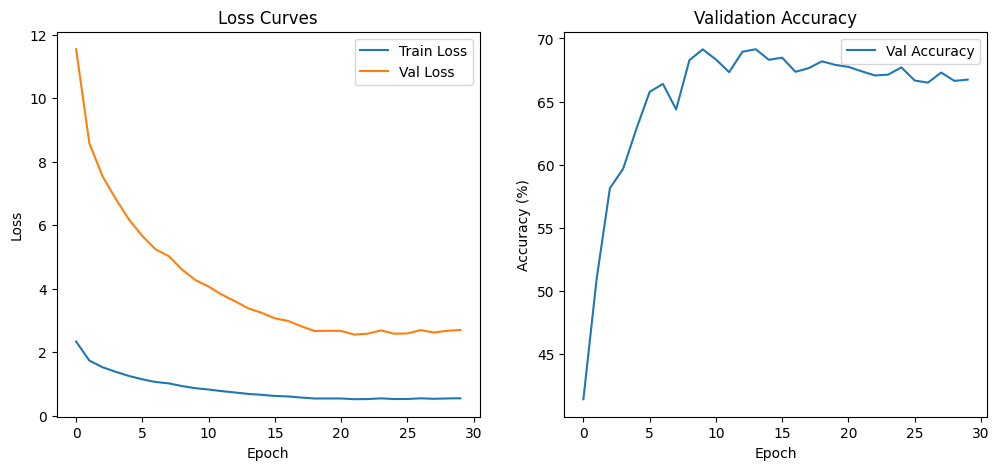

In [10]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

## Visualizing Filters in the First Convolutional Layer

Let's visualize the filters learned by the first convolutional layer (`conv1`). These filters represent the features that the network is looking for in the input images.

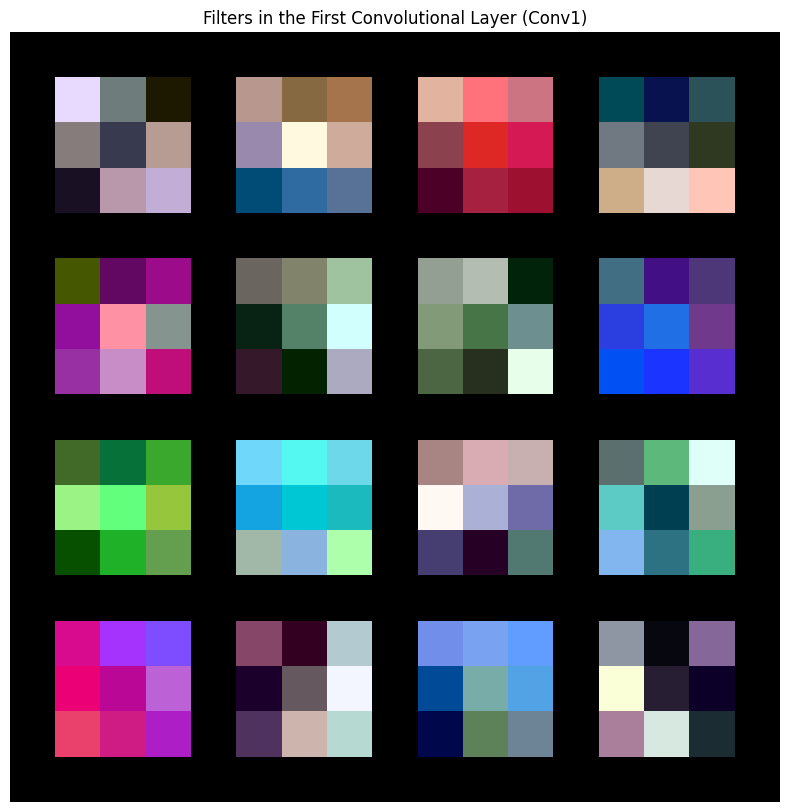

In [11]:
import torchvision.utils as vutils

# Get the weights from the first convolutional layer
# The shape of conv1.weight is (out_channels, in_channels, kernel_height, kernel_width)
weights = net.conv1.weight.cpu().detach()

fig = plt.figure(figsize=(10, 10))

# Create a grid of images for the filters
grid_img = vutils.make_grid(weights, normalize=True, scale_each=True, nrow=4, padding=1)

# Adjust the dimensions for matplotlib (from C, H, W to H, W, C)
plt.imshow(grid_img.permute(1, 2, 0))
plt.title('Filters in the First Convolutional Layer (Conv1)')
plt.axis('off')
plt.show()


#dropout p=0.3

In [12]:
class ModifiedAlexDropout(nn.Module):
  def __init__(self, p):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)
    self.dropout = nn.Dropout(p=p)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [13]:
net = ModifiedAlexDropout(p = 0.3).to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr, momentum = 0.9)

In [14]:
epochs = epochs
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.3621, Validation Accuracy: 38.36, Validation Loss: 11.690961514847189
Epoch: 1, Loss: 1.8344, Validation Accuracy: 48.77, Validation Loss: 9.078989742677424
Epoch: 2, Loss: 1.6385, Validation Accuracy: 55.2, Validation Loss: 8.109513812427279
Epoch: 3, Loss: 1.4908, Validation Accuracy: 58.49, Validation Loss: 7.378687675995163
Epoch: 4, Loss: 1.3634, Validation Accuracy: 63.37, Validation Loss: 6.748081412496446
Epoch: 5, Loss: 1.2772, Validation Accuracy: 64.44, Validation Loss: 6.32112739508665
Epoch: 6, Loss: 1.2203, Validation Accuracy: 64.39, Validation Loss: 6.039684918107866
Epoch: 7, Loss: 1.1440, Validation Accuracy: 67.21, Validation Loss: 5.661968814421304
Epoch: 8, Loss: 1.0969, Validation Accuracy: 67.8, Validation Loss: 5.429068815104569
Epoch: 9, Loss: 1.0491, Validation Accuracy: 68.3, Validation Loss: 5.192597444298901
Epoch: 10, Loss: 1.0114, Validation Accuracy: 68.13, Validation Loss: 5.005693631836131
Epoch: 11, Loss: 0.9749, Validation Accuracy:

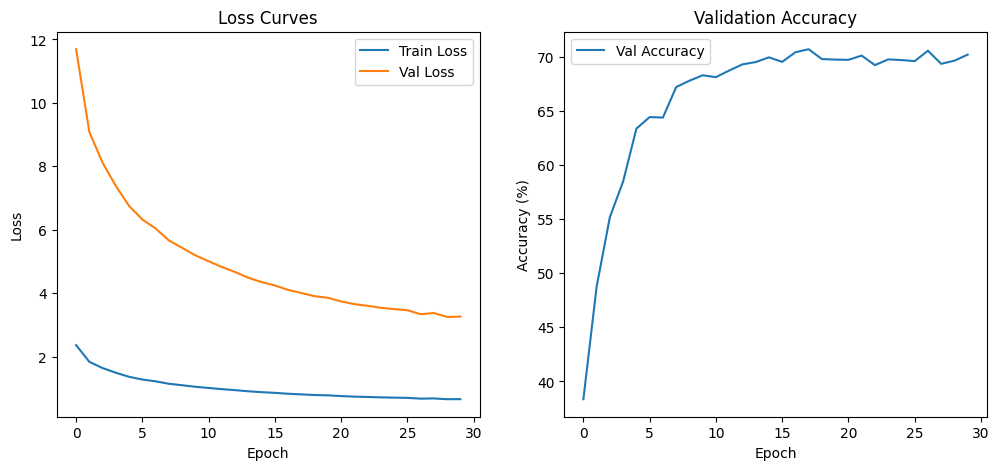

In [15]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

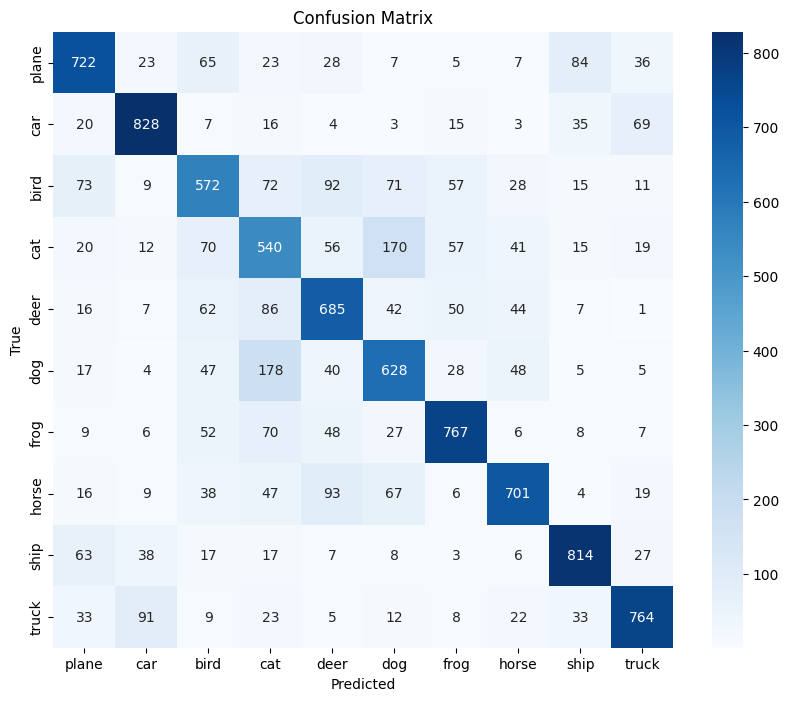

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

#p=0.5

In [17]:
net = ModifiedAlexDropout(p=0.5).to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr, momentum = 0.9)

In [18]:
epochs = epochs
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.4482, Validation Accuracy: 36.52, Validation Loss: 12.11680305909507
Epoch: 1, Loss: 1.9201, Validation Accuracy: 47.72, Validation Loss: 9.503077908407283
Epoch: 2, Loss: 1.7010, Validation Accuracy: 53.26, Validation Loss: 8.418800218195855
Epoch: 3, Loss: 1.5805, Validation Accuracy: 55.76, Validation Loss: 7.8226435478729535
Epoch: 4, Loss: 1.4545, Validation Accuracy: 61.88, Validation Loss: 7.198704882513119
Epoch: 5, Loss: 1.3734, Validation Accuracy: 63.31, Validation Loss: 6.797583964806568
Epoch: 6, Loss: 1.3170, Validation Accuracy: 64.6, Validation Loss: 6.518107869957067
Epoch: 7, Loss: 1.2600, Validation Accuracy: 65.13, Validation Loss: 6.23640886288655
Epoch: 8, Loss: 1.2003, Validation Accuracy: 66.7, Validation Loss: 5.940752859357037
Epoch: 9, Loss: 1.1577, Validation Accuracy: 67.45, Validation Loss: 5.729701964915553
Epoch: 10, Loss: 1.1195, Validation Accuracy: 67.79, Validation Loss: 5.540890085546276
Epoch: 11, Loss: 1.1014, Validation Accuracy

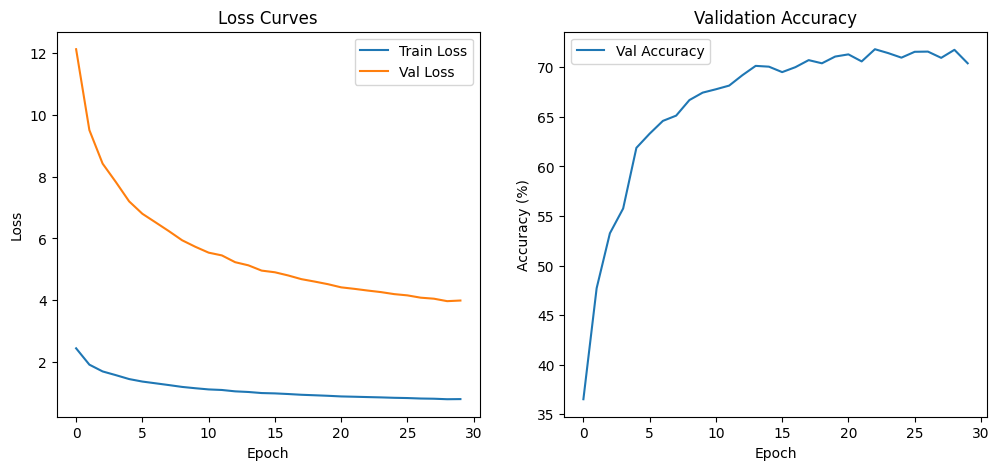

In [19]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

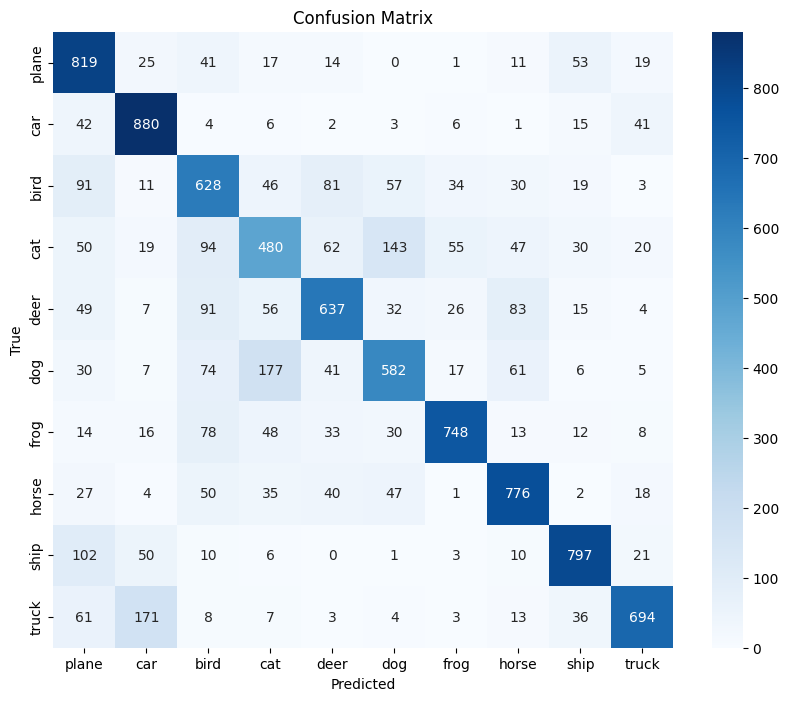

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()